### Imports

In [1]:
from datetime import date
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Define timeframe for stock data (5 years)

In [2]:
end = date.today()
start = end.replace(
    year=end.year - 5,
    day = min(end.day, 28) if end.month == 2 else end.day
)

start_date = start.strftime("%Y-%m-%d")
end_date = end.strftime("%Y-%m-%d")

### Fetch and clean stock data

In [3]:
def get_stock_data(ticker):
    data = yf.download(ticker, start_date, end_date)
    return data

df = get_stock_data("AAPL")
df.reset_index(inplace=True)
df.columns = df.columns.get_level_values(0)
df.columns.name = None
df.head()

[*********************100%***********************]  1 of 1 completed


,Date,Close,High,Low,Open,Volume
0,2021-03-29,118.233322,119.392379,117.590489,118.486563,80819200
1,2021-03-30,116.782066,117.269064,115.769110,116.986605,85671900
2,2021-03-31,118.973541,120.307910,117.999546,118.486544,118323800
3,2021-04-01,119.801468,120.950783,119.304728,120.444309,75089100
4,2021-04-05,122.626045,122.879286,119.869636,120.648835,88651200


### Plot stock data

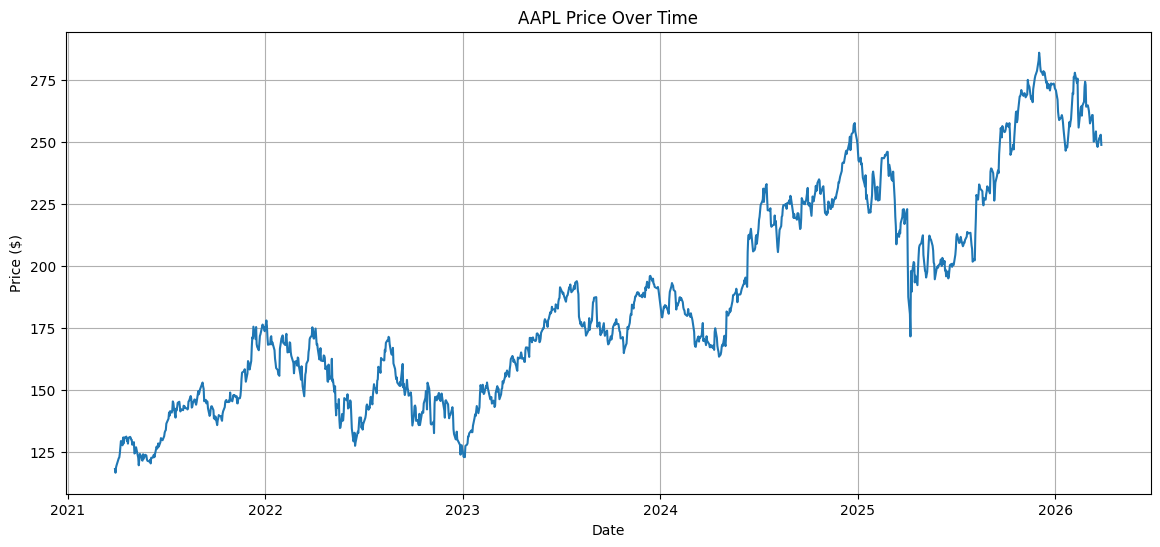

In [4]:
plt.figure(figsize=(14, 6))
plt.grid(True)
plt.plot(df["Date"], df["Close"])
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.title("AAPL Price Over Time")
plt.show()

### Plot the 9, 21, and 100 EMAs

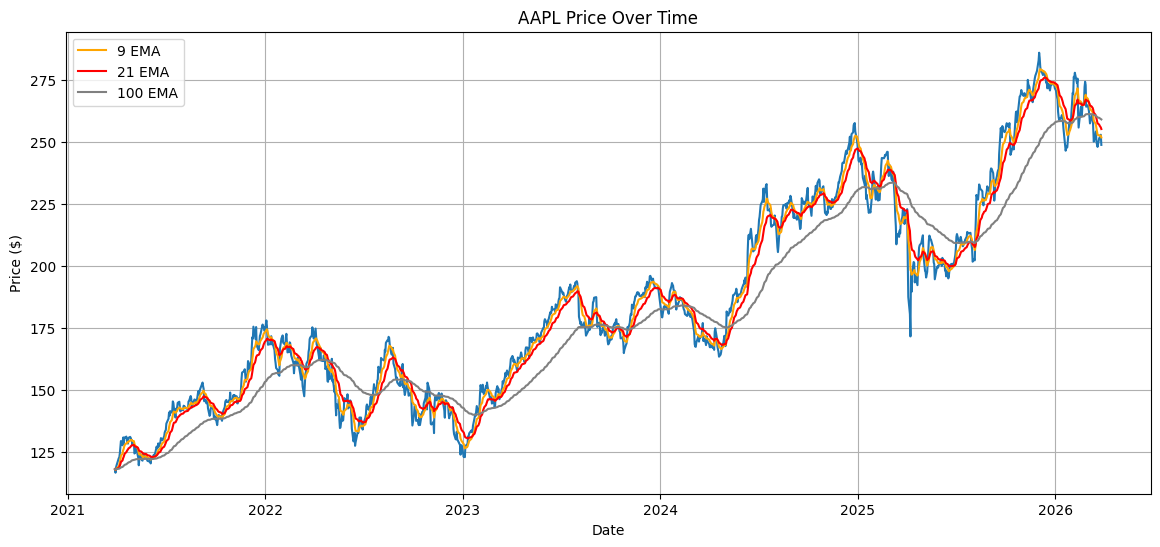

In [5]:
# Calculate EMAs
df["ema9"] = df["Close"].ewm(span=9, adjust=False).mean()
df["ema21"] = df["Close"].ewm(span=21, adjust=False).mean()
df["ema100"] = df["Close"].ewm(span=100, adjust=False).mean()

# Plot price
plt.figure(figsize=(14, 6))
plt.grid(True)
plt.plot(df["Date"], df["Close"])
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.title("AAPL Price Over Time")

# Plot EMAs
plt.plot(df["Date"], df["ema9"], label="9 EMA", color="orange")
plt.plot(df["Date"], df["ema21"], label="21 EMA", color="red")
plt.plot(df["Date"], df["ema100"], label="100 EMA", color="gray")
plt.legend()

### Create 21 EMA distance, 21 EMA slope, and price return features

In [6]:
df["dist_ema21"] = (df["Close"] - df["ema21"]) / df["ema21"]
df["slope_ema21"] = df["ema21"].diff()
df["return"] = df["Close"].pct_change()
df.head()

,Date,Close,High,Low,Open,Volume,ema9,ema21,ema100,dist_ema21,slope_ema21,return
0,2021-03-29,118.233322,119.392379,117.590489,118.486563,80819200,118.233322,118.233322,118.233322,0.000000,NaN,NaN
1,2021-03-30,116.782066,117.269064,115.769110,116.986605,85671900,117.943071,118.101390,118.204584,-0.011171,-0.131932,-0.012275
2,2021-03-31,118.973541,120.307910,117.999546,118.486544,118323800,118.149165,118.180676,118.219811,0.006709,0.079286,0.018766
3,2021-04-01,119.801468,120.950783,119.304728,120.444309,75089100,118.479626,118.328021,118.251131,0.012452,0.147345,0.006959
4,2021-04-05,122.626045,122.879286,119.869636,120.648835,88651200,119.308910,118.718750,118.337763,0.032912,0.390729,0.023577


In [7]:
df = df.dropna().reset_index(drop=True)
df.drop(columns=["High", "Low", "Open", "Volume"], inplace=True)
df.head()

,Date,Close,ema9,ema21,ema100,dist_ema21,slope_ema21,return
0,2021-03-30,116.782066,117.943071,118.101390,118.204584,-0.011171,-0.131932,-0.012275
1,2021-03-31,118.973541,118.149165,118.180676,118.219811,0.006709,0.079286,0.018766
2,2021-04-01,119.801468,118.479626,118.328021,118.251131,0.012452,0.147345,0.006959
3,2021-04-05,122.626045,119.308910,118.718750,118.337763,0.032912,0.390729,0.023577
4,2021-04-06,122.927979,120.032723,119.101408,118.428659,0.032129,0.382657,0.002462


### Use a 70/30 train/test split

In [8]:
df.shape

(1255, 8)

In [9]:
split = int(len(df) * 0.7)
train = df[:split]
test = df[split:]

In [10]:
print(train.shape)
train.head()

(878, 8)


,Date,Close,ema9,ema21,ema100,dist_ema21,slope_ema21,return
0,2021-03-30,116.782066,117.943071,118.101390,118.204584,-0.011171,-0.131932,-0.012275
1,2021-03-31,118.973541,118.149165,118.180676,118.219811,0.006709,0.079286,0.018766
2,2021-04-01,119.801468,118.479626,118.328021,118.251131,0.012452,0.147345,0.006959
3,2021-04-05,122.626045,119.308910,118.718750,118.337763,0.032912,0.390729,0.023577
4,2021-04-06,122.927979,120.032723,119.101408,118.428659,0.032129,0.382657,0.002462


In [11]:
print(test.shape)
test.head()

(377, 8)


,Date,Close,ema9,ema21,ema100,dist_ema21,slope_ema21,return
878,2024-09-25,224.892700,223.540169,222.341683,211.404977,0.011473,0.255102,-0.004398
879,2024-09-26,226.035187,224.039173,222.677456,211.694684,0.015079,0.335773,0.005080
880,2024-09-27,226.303406,224.492019,223.007088,211.983966,0.014781,0.329632,0.001187
881,2024-09-30,231.479446,225.889505,223.777302,212.370015,0.034419,0.770214,0.022872
882,2024-10-01,224.733749,225.658354,223.864252,212.614841,0.003884,0.086950,-0.029142


### Normalize the dataset

In [12]:
from sklearn.preprocessing import MinMaxScaler

In [13]:
# MinMaxScaler has default param feature_range=(0,1)
scaler = MinMaxScaler()

features = ["Close", "ema21", "dist_ema21", "slope_ema21", "return"]
window = 60

train_features = train[features]
test_features = test[features]

# Scale training data
train_features_scaled = scaler.fit_transform(train_features)

# Scale testing data
prev_window_features = train_features.tail(window)
test_features = pd.concat([prev_window_features, test_features], ignore_index=True)
test_features_scaled = scaler.transform(test_features)

print(train_features_scaled.shape)
print(test_features_scaled.shape)

(878, 5)
(437, 5)


In [14]:
print(train_features_scaled[:5])
print(train_features_scaled[-5:])

[[0.         0.         0.44159129 0.40206604 0.31428128]
 [0.0188537  0.00075789 0.53073676 0.46312074 0.52450284]
 [0.02597653 0.00216635 0.55937146 0.48279356 0.44454151]
 [0.05027694 0.00590129 0.6613799  0.55314611 0.55709016]
 [0.05287453 0.00955907 0.65747347 0.55081272 0.41408727]]
[[0.88155052 0.97587074 0.47596083 0.41297628 0.51924929]
 [0.9514656  0.98211422 0.64474382 0.62900372 0.64844226]
 [0.94573875 0.98721166 0.61738696 0.59434756 0.3775842 ]
 [0.93095252 0.99035217 0.57117068 0.53517049 0.34606867]
 [0.93864481 0.99398416 0.58258697 0.55003276 0.42432592]]


In [15]:
print(test_features_scaled[:5])
print(test_features_scaled[-5:])

[[0.84573307 0.82803933 0.74959154 0.73967199 0.59452476]
 [0.87578403 0.8400776  0.80211231 0.80423672 0.50739831]
 [0.88671171 0.85212527 0.80049494 0.80452077 0.43676783]
 [0.92760476 0.86720821 0.87401639 0.89630682 0.54383777]
 [0.94023992 0.88219622 0.8688555  0.8934363  0.441697  ]]
[[1.15891982 1.32740909 0.39100847 0.28186529 0.49299646]
 [1.16021025 1.32277939 0.40313842 0.30020112 0.4014509 ]
 [1.16864135 1.31942218 0.42892205 0.3386809  0.42378703]
 [1.17096425 1.31660479 0.439849   0.35500531 0.40465024]
 [1.13577718 1.31048937 0.37229833 0.25527322 0.28787818]]


### Create training sequences

In [16]:
x_train = []
y_train = []

# For each timestamp (row) x, grab the (window) timestamps before it and add them as a singular element to x_train. Add timestamp x as an element to y_train.
for i in range(window, train_features_scaled.shape[0]):
    x_train.append(train_features_scaled[i - window : i])
    y_train.append(train_features_scaled[i, 0])

x_train = np.array(x_train)
y_train = np.array(y_train)

print(x_train.shape)
print(y_train.shape)

(818, 60, 5)
(818,)


### Create testing sequences

In [17]:
x_test = []
y_test = []

for i in range(window, test_features_scaled.shape[0]):
    x_test.append(test_features_scaled[i - window : i])
    y_test.append(test_features_scaled[i, 0])

x_test = np.array(x_test)
y_test = np.array(y_test)

print(x_test.shape)
print(y_test.shape)

(377, 60, 5)
(377,)


### Build LSTM model

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense

In [19]:
model = Sequential()

model.add(Input(shape=(x_train.shape[1], x_train.shape[2])))

model.add(LSTM(units=64, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=32))
model.add(Dropout(0.2))

# model.add(LSTM(units=80, return_sequences=True))
# model.add(Dropout(0.4))

# model.add(LSTM(units=120))
# model.add(Dropout(0.5))

model.add(Dense(units=1))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,369 (118.63 KB)

 Trainable params: 30,369 (118.63 KB)

 Non-trainable params: 0 (0.00 B)

### Train model

In [20]:
import tensorflow as tf

In [21]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=[tf.keras.metrics.MeanAbsoluteError()]
)

model.fit(x_train, y_train, epochs=100)

Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0248 - mean_absolute_error: 0.1147
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0078 - mean_absolute_error: 0.0671
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0056 - mean_absolute_error: 0.0570
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0051 - mean_absolute_error: 0.0549
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0045 - mean_absolute_error: 0.0507
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0039 - mean_absolute_error: 0.0477
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0044 - mean_absolute_error: 0.0505
Epoch 8/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0036 - mean_absolute_error: 0.0472
Epoch 9/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0042 - mean_absolute_error: 0.0480
Epoch 10/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0040 - mean_absolute_error: 0.0480
Epoch 11/100
26/26 ━━━━━━━━━━

### Make prediction

In [22]:
y_pred = model.predict(x_test)
print(y_pred.shape)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
(377, 1)


In [23]:
print(y_test[:10])

[0.93009779 0.93992683 0.94223438 0.98676491 0.9287303  0.93360216
 0.92411482 0.93377321 0.89009767 0.92496955]


In [24]:
print(y_pred[:10])

[[0.9447181 ]
 [0.9367271 ]
 [0.9471805 ]
 [0.9480405 ]
 [0.9907595 ]
 [0.9339293 ]
 [0.94403577]
 [0.9320748 ]
 [0.9401072 ]
 [0.8988828 ]]


### Plot prediction

In [25]:
# inverse_transform() now expects shape of (n_samples, 5), but y_pred has shape (n_samples, 1)
# solution: make dummy np arrays of shape (n_samples, 5)
dummy_pred = np.zeros((len(y_pred), 5))
dummy_test = np.zeros((len(y_test), 5))

dummy_pred[:, 0] = y_pred.flatten()
dummy_test[:, 0] = y_test

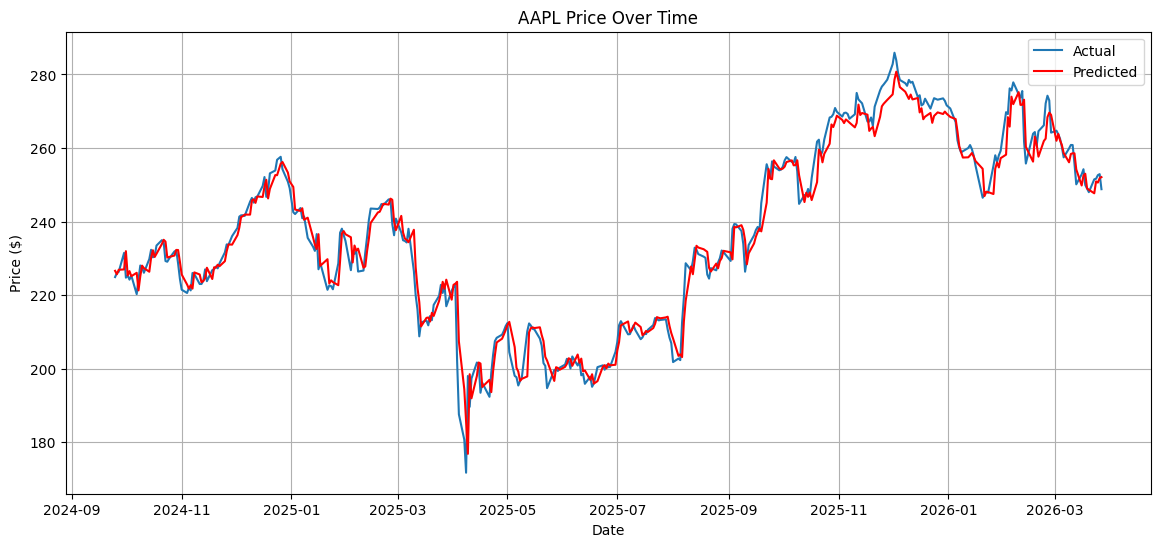

In [26]:
y_pred_prices = scaler.inverse_transform(dummy_pred)[:, 0]
y_test_prices = scaler.inverse_transform(dummy_test)[:, 0]

# Plot price
plt.figure(figsize=(14, 6))
plt.grid(True)
plt.plot(test["Date"], y_test_prices, label="Actual")
plt.plot(test["Date"], y_pred_prices, label="Predicted", color="red")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.title("AAPL Price Over Time")
plt.legend()